# 1. 함수 $f(x)=2*sin(x)+0.5*x$의 최소값 탐색

## 1-1. 미분법

기울기가 0인 지점들: [-4.459708725242611, -1.8234765819369754, 1.8234765819369754, 4.459708725242611, 8.106661889116562, 10.742894032422196]
최소값 :  -2.848229964072196


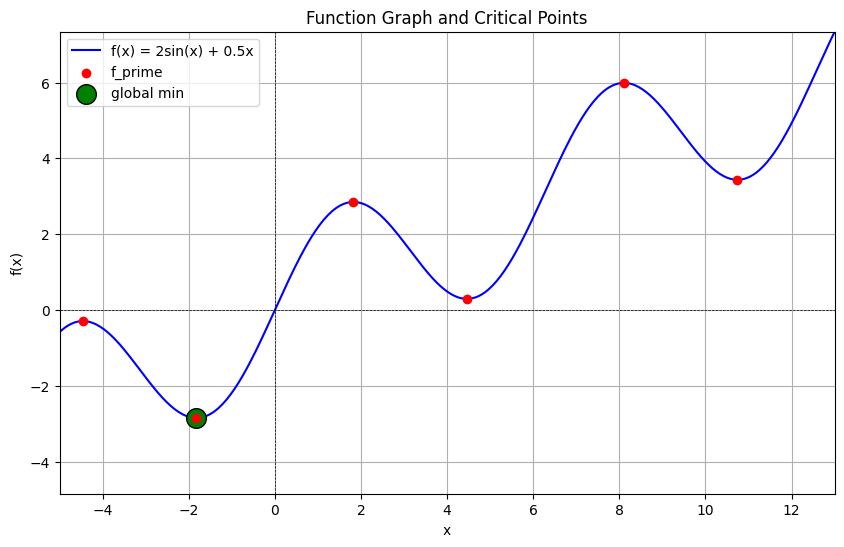

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return 2 * np.sin(x) + 0.5 * x

x_values = np.linspace(-5, 13, 400)  # -5부터 13까지 400개의 점 생성
y_values = f(x_values)  # y 값 계산

def critical_points_in_range(): # 기울기가 0이 되는 지점 탐색
    cos_value = -0.25
    angles = np.arccos(cos_value)  # arccos를 통해 주어진 값의 각도를 구함
    solutions = [angles, -angles]

    n_values = np.arange(-3, 4)  # -3π 부터 3π까지
    for n in n_values:
        for solution in solutions:
            x_value = solution + n * 2 * np.pi
            if -5 <= x_value <= 13:
                yield x_value

# 기울기가 0인 x 값들
critical_points = list(critical_points_in_range())
critical_points.sort()

# y 값 계산 (x 값과 그에 대응하는 y 값을 튜플로 저장)
y_values = [(x, f(x)) for x in critical_points]

# 가장 작은 y값의 위치 찾기
min_y_point = min(y_values, key=lambda item: item[1])

print("기울기가 0인 지점들:", critical_points)
print("최소값 : ", min_y_point[1])

# 그래프 그리기
plt.figure(figsize=(10, 6))
plt.plot(x_values, f(x_values), label='f(x) = 2sin(x) + 0.5x', color='blue')
plt.scatter(critical_points, f(np.array(critical_points)), color='red', label='f_prime', zorder=10)
plt.scatter(min_y_point[0], min_y_point[1], color='green', s=200, label='global min', zorder=6, edgecolor='black')
plt.title('Function Graph and Critical Points')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.axhline(0, color='black', linewidth=0.5, ls='--')
plt.axvline(0, color='black', linewidth=0.5, ls='--')
plt.grid()
plt.legend()
plt.xlim(-5, 13)
plt.ylim(min(f(x_values))-2, max(f(x_values)))
plt.show()

## 1-2. 뉴턴법

In [2]:
import numpy as np

# 도함수 정의
def f_prime(x): 
    return 2 * np.cos(x) + 0.5 

# 초기값 설정
x0 = 13
tolerance = 1e-6  # 수렴 허용 오차
max_iterations = 100  # 최대 반복 횟수
iteration = 0

# 뉴턴법 적용
while iteration < max_iterations:
    slope = f_prime(x0)  # 현재 기울기 계산
    
    # 기울기가 0에 도달할 때까지 이동
    if slope > 0:  # 기울기가 양수면 왼쪽으로
        x1 = x0 - slope * 0.1  # 작은 스텝으로 왼쪽으로 이동
    else:  # 기울기가 음수면 오른쪽으로
        x1 = x0 - slope * 0.1  # 작은 스텝으로 오른쪽으로 이동

    # x의 범위 제한
    if x1 < -5 or x1 > 13:
        break

    # 기울기가 0인지 검사
    if abs(f_prime(x1)) < tolerance:
        break

    x0 = x1  # 업데이트
    iteration += 1

x1, f(x1)  # 기울기가 0인 지점과 해당 함수 값 반환

(10.742894484624905, 3.434955343107588)

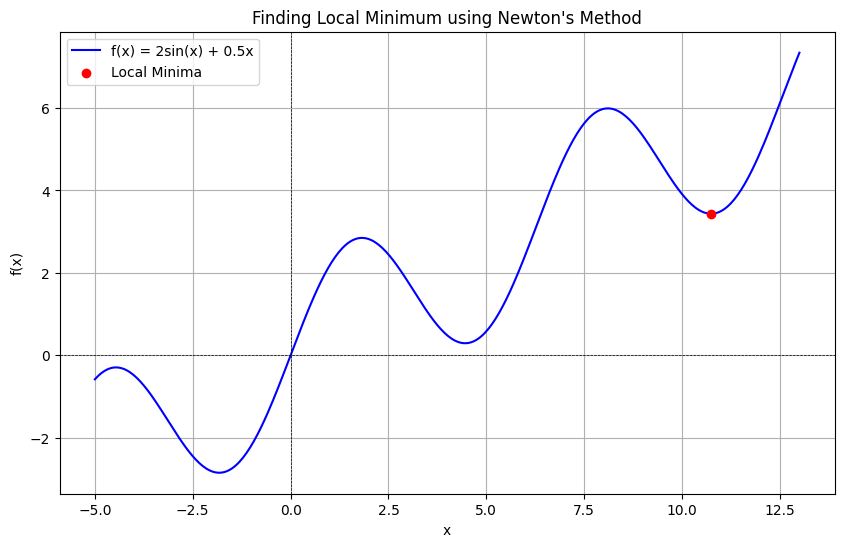

In [3]:
x_values = np.linspace(-5, 13, 400)
y_values = f(x_values)

plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, label='f(x) = 2sin(x) + 0.5x', color='blue')
plt.scatter(x1, f(x1), color='red', label='Local Minima', zorder=5)
plt.title('Finding Local Minimum using Newton\'s Method')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
plt.grid()
plt.legend()
plt.show()

## 1-3. 경사하강법

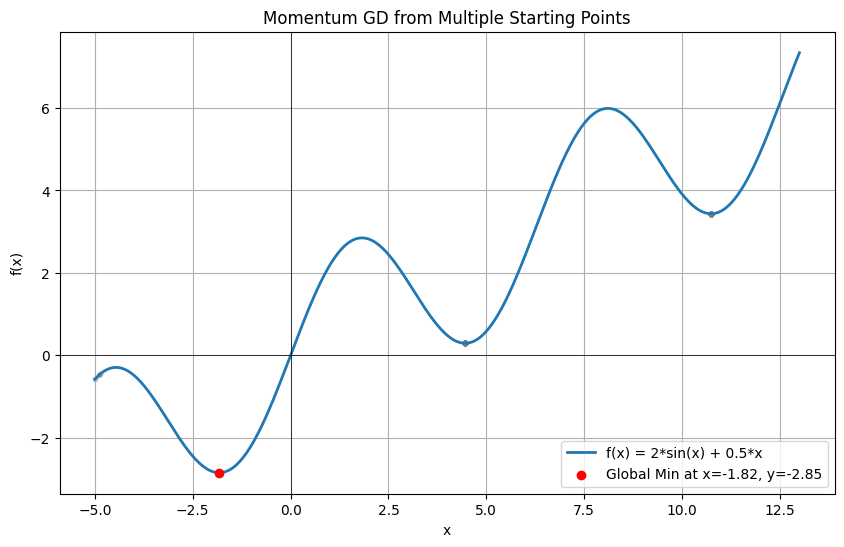

momentum_score: -1.3636363636363633, 
x: -1.8234684114155872, 
y: -2.8482299640075586


In [4]:
# sympy 함수 사용을 위한 재정의
import sympy as sp

# 심볼릭 변수 및 함수 정의
x_sym = sp.symbols('x')
f_sym = 2 * sp.sin(x_sym) + 0.5 * x_sym

# 도함수 계산
f_prime = sp.diff(f_sym, x_sym)

# 수치 계산을 위한 함수 변환
f_lambdified = sp.lambdify(x_sym, f_sym, modules=["numpy"])
f_prime_lambdified = sp.lambdify(x_sym, f_prime, modules=["numpy"])

# 모멘텀을 사용하는 경사하강법 함수 정의
def gradient_descent_with_momentum(f_prime, x0, learning_rate=0.01, momentum=0.9, tol=1e-6, max_iter=1000, x_min=-5, x_max=13):
    x = x0
    v = 0
    for _ in range(max_iter):
        grad = f_prime(x)
        v = momentum * v - learning_rate * grad
        x_new = x + v
        if x_new < x_min or x_new > x_max:
            break
        if abs(x_new - x) < tol:
            return x_new
        x = x_new
    return x

# 초기값을 linspace로 설정
initial_values = np.linspace(-5, 13, 100)
results = []

# 각 초기값마다 경사하강법 실행
for x0 in initial_values:
    x_opt = gradient_descent_with_momentum(
        f_prime_lambdified, x0, learning_rate=0.1, momentum=0.9, max_iter=1000
    )
    y_opt = f_lambdified(x_opt)
    results.append((x0, x_opt, y_opt))

# 최소값 탐색
best_result = min(results, key=lambda x: x[2])  # y_opt 기준 최소값

plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, label='f(x) = 2*sin(x) + 0.5*x', linewidth=2)

# 여러 초기값에서 수렴한 최적점 표시
for _, x_opt, y_opt in results:
    plt.scatter(x_opt, y_opt, color='gray', alpha=0.4, s=10)

# 최적 최소값 표시
plt.scatter(best_result[1], best_result[2], color='red', label=f"Global Min at x={best_result[1]:.2f}, y={best_result[2]:.2f}", zorder=5)

plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.title("Momentum GD from Multiple Starting Points")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()

best_result
print(f'momentum_score: {best_result[0]}, \nx: {best_result[1]}, \ny: {best_result[2]}')

## 1-4. 유전알고리즘을 이용해 최솟값 탐색

In [5]:
import random
import numpy as np
from itertools import product
from toolbox import (
    selection_proportional, selection_rank, selection_rank_with_elite,
    selection_stochastic_universal_sampling, selection_tournament,
    crossover_blend, crossover_linear, crossover_uniform,
    crossover_n_point, crossover_one_point,
    mutation_random_deviation, mutation_bit_flip,
    mutation_fitness_driven_random_deviation, mutation_fitness_driven_bit_flip
)

def func(x):
    return 2 * np.sin(x) + 0.5 * x

class RealIndividual:
    def __init__(self, gene_list) -> None:
        if isinstance(gene_list, RealIndividual):
            self.gene_list = gene_list.gene_list
        else:
            self.gene_list = gene_list if isinstance(gene_list, list) else [gene_list]
        self.gene_list[0] = max(min(self.gene_list[0], 13), -5)
        self.fitness = -func(self.gene_list[0])

    def __str__(self):
        return f'x: {self.gene_list[0]}, f(x): {func(self.gene_list[0])}'

class BinaryIndividual:
    def __init__(self, gene_list=None, bits=16):
        self.bits = bits
        self.min_value = -5
        self.max_value = 13

        if gene_list is None:
            self.gene_list = [random.randint(0, 1) for _ in range(bits)]
        else:
            self.gene_list = gene_list

        self.x = self._decode_binary()
        self.fitness = -func(self.x)

    def _decode_binary(self):
        sign = -1 if self.gene_list[0] == 1 else 1
        value = 0
        for i, bit in enumerate(self.gene_list[1:], 1):
            value = value * 2 + bit
        max_binary = 2 ** (self.bits - 1) - 1
        scaled = sign * (value / max_binary) * self.max_value
        return max(min(scaled, self.max_value), self.min_value)

    def __str__(self):
        binary = ''.join(map(str, self.gene_list))
        return f'Binary: {binary}, x: {self.x:.4f}, f(x): {func(self.x):.4f}'

class AdaptiveGA:
    def __init__(self, encoding_type='real', population_size=50, max_generations=200,
                 initial_crossover_prob=0.9, final_crossover_prob=0.7,
                 initial_mutation_prob=0.3, final_mutation_prob=0.1,
                 elite_size=3, bits=20):
        self.encoding_type = encoding_type
        self.population_size = population_size
        self.max_generations = max_generations
        self.initial_crossover_prob = initial_crossover_prob
        self.final_crossover_prob = final_crossover_prob
        self.initial_mutation_prob = initial_mutation_prob
        self.final_mutation_prob = final_mutation_prob
        self.elite_size = elite_size
        self.bits = bits
        self.convergence_threshold = 1e-12
        self.convergence_generations = 10

    def get_adaptive_rates(self, generation):
        """세대에 따라 교차/돌연변이 확률 조정"""
        progress = generation / self.max_generations
        crossover_prob = self.initial_crossover_prob - (self.initial_crossover_prob - self.final_crossover_prob) * progress
        mutation_prob = self.initial_mutation_prob - (self.initial_mutation_prob - self.final_mutation_prob) * progress
        return crossover_prob, mutation_prob

    def create_individual(self):
        """실수/이진 인코딩에 따른 개체 생성"""
        if self.encoding_type == 'real':
            return RealIndividual([random.uniform(-15, 15)])
        else:
            return BinaryIndividual(bits=self.bits)

    def hybrid_selection(self, population, generation):
        """하이브리드 선택 전략"""
        if generation % 2 == 0:
            return selection_rank_with_elite(population, elite_size=self.elite_size)
        else:
            return selection_tournament(population, group_size=3)

    def run(self, selection_method, crossover_tuple, mutation_tuple):
        """개선된 유전 알고리즘 실행"""
        population = [self.create_individual() for _ in range(self.population_size)]
        best_ever = min(population, key=lambda x: func(x.gene_list[0] if self.encoding_type == 'real' else x.x))
        
        prev_best_fx = float('inf')
        convergence_count = 0
        
        crossover_method, crossover_params = crossover_tuple
        mutation_method, mutation_params = mutation_tuple
        
        for generation in range(self.max_generations):
            # 적응적 확률 조정
            crossover_prob, mutation_prob = self.get_adaptive_rates(generation)
            
            # 하이브리드 선택 또는 일반 선택
            if selection_method == 'hybrid':
                selected = self.hybrid_selection(population, generation)
            else:
                selected = selection_method(population)

            # 교차
            offspring = []
            for p1, p2 in zip(selected[::2], selected[1::2]):
                if random.random() < crossover_prob:
                    if self.encoding_type == 'real':
                        # 각 교차 연산자에 맞는 파라미터 적용
                        current_params = crossover_params.copy()
                        if 'alpha' in current_params and generation >= self.max_generations // 2:
                            current_params['alpha'] *= 0.6
                        elif 'prop' in current_params and generation >= self.max_generations // 2:
                            current_params['prop'] = min(0.7, current_params['prop'] * 1.2)
                        c1, c2 = crossover_method(p1.gene_list, p2.gene_list, **current_params)
                    else:
                        c1, c2 = crossover_method(p1.gene_list, p2.gene_list, **crossover_params)
                    offspring.extend([
                        RealIndividual(c1) if self.encoding_type == 'real' else BinaryIndividual(c1, self.bits),
                        RealIndividual(c2) if self.encoding_type == 'real' else BinaryIndividual(c2, self.bits)
                    ])
                else:
                    offspring.extend([p1, p2])

            # 돌연변이
            mutated_offspring = []
            for ind in offspring:
                if random.random() < mutation_prob:
                    if self.encoding_type == 'real':
                        # 세대에 따라 sigma 값 조정
                        current_sigma = mutation_params['sigma'] if generation < self.max_generations // 2 else mutation_params['sigma'] * 0.5
                        current_params = {**mutation_params, 'sigma': current_sigma}
                        mutated = mutation_method(ind.gene_list, **current_params)
                    else:
                        mutated = mutation_method(ind.gene_list, **mutation_params)
                    mutated_offspring.append(
                        RealIndividual(mutated) if self.encoding_type == 'real' else BinaryIndividual(mutated, self.bits)
                    )
                else:
                    mutated_offspring.append(ind)

            # 엘리트 보존
            population = sorted(mutated_offspring, 
                             key=lambda x: func(x.gene_list[0] if self.encoding_type == 'real' else x.x))
            if self.elite_size > 0:
                elite = sorted(population, 
                             key=lambda x: func(x.gene_list[0] if self.encoding_type == 'real' else x.x))[:self.elite_size]
                population = elite + population[:-self.elite_size]

            # 현재 세대의 최소값 갱신
            current_best = min(population, 
                             key=lambda x: func(x.gene_list[0] if self.encoding_type == 'real' else x.x))
            current_fx = func(current_best.gene_list[0] if self.encoding_type == 'real' else current_best.x)

            if current_fx < func(best_ever.gene_list[0] if self.encoding_type == 'real' else best_ever.x):
                best_ever = current_best

            # 수렴 검사
            if abs(current_fx - prev_best_fx) < self.convergence_threshold:
                convergence_count += 1
            else:
                convergence_count = 0
            
            if convergence_count >= self.convergence_generations:
                break
                
            prev_best_fx = current_fx

        return {
            'generations': generation + 1,
            'best_fx': func(best_ever.gene_list[0] if self.encoding_type == 'real' else best_ever.x),
            'best_x': best_ever.gene_list[0] if self.encoding_type == 'real' else best_ever.x,
            'binary': ''.join(map(str, best_ever.gene_list)) if self.encoding_type == 'binary' else None
        }


# 실험 설정 및 실행
experiment_settings = [
    {
        'encoding_type': 'real',
        'population_size': 100,
        'max_generations': 200,
        'initial_crossover_prob': 0.9,
        'final_crossover_prob': 0.7,
        'initial_mutation_prob': 0.3,
        'final_mutation_prob': 0.1,
        'elite_size': 3,
    },
    {
        'encoding_type': 'binary',
        'population_size': 100,
        'max_generations': 200,
        'initial_crossover_prob': 0.9,
        'final_crossover_prob': 0.7,
        'initial_mutation_prob': 0.3,
        'final_mutation_prob': 0.1,
        'elite_size': 3,
        'bits': 24,
    }
]

best_overall = None

for setting in experiment_settings:
    print(f"\n{setting['encoding_type'].upper()} 인코딩 실험 시작...")

    ga = AdaptiveGA(**setting)
    results = []

    if setting['encoding_type'] == 'real':
        real_crossover_methods = [
            (crossover_blend, {'alpha': 0.5}),
            (crossover_linear, {'alpha': 0.7}),
            (crossover_uniform, {'prop': 0.5})
        ]
        real_mutation_methods = [
            (mutation_random_deviation, {'mu': 0, 'sigma': 1.0, 'p': 0.1}),
            (mutation_fitness_driven_random_deviation, {'mu': 0, 'sigma': 1.0, 'p': 0.1, 'max_tries': 3})
        ]
        combinations = [
            (selection_rank_with_elite, real_crossover_methods[0], real_mutation_methods[0]),
            (selection_tournament, real_crossover_methods[1], real_mutation_methods[0]),
            ('hybrid', real_crossover_methods[2], real_mutation_methods[1]),
        ]
    else:
        binary_crossover_methods = [
            (crossover_one_point, {}),
            (crossover_n_point, {'n': 2}),
            (crossover_uniform, {'prop': 0.5})
        ]
        binary_mutation_methods = [
            (mutation_bit_flip, {}),
            (mutation_fitness_driven_bit_flip, {'max_tries': 3})
        ]
        combinations = [
            (selection_rank_with_elite, binary_crossover_methods[0], binary_mutation_methods[0]),
            (selection_tournament, binary_crossover_methods[1], binary_mutation_methods[0]),
            ('hybrid', binary_crossover_methods[2], binary_mutation_methods[1]),
        ]

    for selection, crossover, mutation in combinations:
        result = ga.run(selection, crossover, mutation)
        result_summary = {
            'encoding': setting['encoding_type'],
            'selection': selection if isinstance(selection, str) else selection.__name__,
            'crossover': crossover[0].__name__,
            'mutation': mutation[0].__name__,
            **result
        }
        results.append(result_summary)

        print(f"- 조합: {result_summary['selection']} / {result_summary['crossover']} / {result_summary['mutation']}")
        print(f"  -> 세대 수: {result_summary['generations']}, f(x): {result_summary['best_fx']:.6f}, x: {result_summary['best_x']:.6f}")

        if best_overall is None or result_summary['best_fx'] < best_overall['best_fx']:
            best_overall = result_summary

# 최종 최적 결과 출력
print("\n===== 최종 최적 결과 =====")
print(f"- 인코딩 방식: {best_overall['encoding']}")
print(f"- 선택 연산자: {best_overall['selection']}")
print(f"- 교차 연산자: {best_overall['crossover']}")
print(f"- 돌연변이 연산자: {best_overall['mutation']}")
print(f"- 세대 수: {best_overall['generations']}")
print(f"- 최적 x: {best_overall['best_x']:.6f}")
print(f"- 최소 f(x): {best_overall['best_fx']:.6f}")
if best_overall['encoding'] == 'binary':
    print(f"- 이진 표현: {best_overall['binary']}")



REAL 인코딩 실험 시작...
- 조합: selection_rank_with_elite / crossover_blend / mutation_random_deviation
  -> 세대 수: 17, f(x): -2.848218, x: -1.820000
- 조합: selection_tournament / crossover_linear / mutation_random_deviation
  -> 세대 수: 14, f(x): -2.848218, x: -1.820000
- 조합: hybrid / crossover_uniform / mutation_fitness_driven_random_deviation
  -> 세대 수: 18, f(x): -2.847475, x: -1.795594

BINARY 인코딩 실험 시작...
- 조합: selection_rank_with_elite / crossover_one_point / mutation_bit_flip
  -> 세대 수: 26, f(x): -2.848209, x: -1.828125
- 조합: selection_tournament / crossover_n_point / mutation_bit_flip
  -> 세대 수: 25, f(x): -2.848209, x: -1.828125
- 조합: hybrid / crossover_uniform / mutation_fitness_driven_bit_flip
  -> 세대 수: 24, f(x): -2.848209, x: -1.828125

===== 최종 최적 결과 =====
- 인코딩 방식: real
- 선택 연산자: selection_rank_with_elite
- 교차 연산자: crossover_blend
- 돌연변이 연산자: mutation_random_deviation
- 세대 수: 17
- 최적 x: -1.820000
- 최소 f(x): -2.848218
